In [50]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import randint

# prep
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.datasets import make_classification
from sklearn.preprocessing import binarize, LabelEncoder, MinMaxScaler

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Validation libraries
from sklearn import metrics
from sklearn.metrics import accuracy_score, mean_squared_error, precision_recall_curve
from sklearn.model_selection import cross_val_score

#Neural Network
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

#Bagging
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

#Naive bayes
from sklearn.naive_bayes import GaussianNB 

#Stacking
from mlxtend.classifier import StackingClassifier

In [51]:
#reading in CSV's from a file path
train_df = pd.read_csv('survey.csv')

In [52]:
print(train_df.shape)

(1259, 27)


terdapat 27 fitur dan 1259 data

In [53]:
print(train_df.describe())

                Age
count  1.259000e+03
mean   7.942815e+07
std    2.818299e+09
min   -1.726000e+03
25%    2.700000e+01
50%    3.100000e+01
75%    3.600000e+01
max    1.000000e+11


In [54]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

### cleaning data

In [55]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False) *100
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)
print(missing_data)

                           Total    Percent
comments                    1095  86.973789
state                        515  40.905481
work_interfere               264  20.969023
self_employed                 18   1.429706
seek_help                      0   0.000000
obs_consequence                0   0.000000
mental_vs_physical             0   0.000000
phys_health_interview          0   0.000000
mental_health_interview        0   0.000000
supervisor                     0   0.000000
coworkers                      0   0.000000
phys_health_consequence        0   0.000000
mental_health_consequence      0   0.000000
leave                          0   0.000000
anonymity                      0   0.000000
Timestamp                      0   0.000000
wellness_program               0   0.000000
Age                            0   0.000000
benefits                       0   0.000000
tech_company                   0   0.000000
remote_work                    0   0.000000
no_employees                   0

Analisis Fitur:
* comments (86,97%): Kolom ini memiliki persentase data yang cukup tinggi, menunjukkan bahwa sebagian besar dataset mencakup data untuk comments. Ini bisa menjadi fitur yang penting, karena dapat memberikan wawasan tentang umpan balik atau tanggapan terbuka dari pengguna.
* state (40,91%): Sekitar 41% dari dataset memiliki data di kolom state, yang mungkin mewakili data geografis atau kategori lainnya. Data pada kolom ini cukup signifikan, meskipun lebih sedikit dibandingkan dengan comments.
* work_interfere (20,97%): Sekitar 21% dari dataset memiliki nilai untuk work_interfere. Ini bisa merujuk pada bagaimana pekerjaan memengaruhi kesehatan mental atau aspek lainnya. Kolom ini tergolong cukup jarang terisi.
* self_employed (1,43%): Hanya sebagian kecil dari dataset yang memiliki data mengenai apakah orang tersebut bekerja sendiri. Kolom ini tampaknya memiliki cakupan yang terbatas dan mungkin tidak terlalu berguna kecuali ada data tambahan.
* seek_help, obs_consequence, mental_vs_physical, dll. (0,00%): Kolom-kolom ini memiliki nol nilai non-null, yang berarti tidak ada data yang tersedia untuk fitur-fitur ini dalam dataset. Ini bisa menunjukkan bahwa fitur-fitur ini tidak dikumpulkan atau ada kesalahan dalam pemrosesan data.

In [56]:
#dealing with missing data
train_df = train_df.drop(['comments'], axis= 1)
train_df = train_df.drop(['state'], axis= 1)
train_df = train_df.drop(['Timestamp'], axis= 1)

train_df.isnull().sum().max()
train_df.head(5)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


langsung hapus saja fitur comments, state, timestamp dikarenakan ini tidak sesuai sehingga bisa dikatakan data ini tidak terpakai

lalu sisihkan masing masing fitur berdasarkan tipe datanya

In [57]:
# Assign default values for each data type
defaultInt = 0
defaultString = 'NaN'
defaultFloat = 0.0

# Create lists by data tpe
intFeatures = ['Age']
stringFeatures = ['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'work_interfere',
                 'no_employees', 'remote_work', 'tech_company', 'anonymity', 'leave', 'mental_health_consequence',
                 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                 'mental_vs_physical', 'obs_consequence', 'benefits', 'care_options', 'wellness_program',
                 'seek_help']
floatFeatures = []

# Clean the NaN's
for feature in train_df:
    if feature in intFeatures:
        train_df[feature] = train_df[feature].fillna(defaultInt)
    elif feature in stringFeatures:
        train_df[feature] = train_df[feature].fillna(defaultString)
    elif feature in floatFeatures:
        train_df[feature] = train_df[feature].fillna(defaultFloat)
    else:
        print('Error: Feature %s not recognized.' % feature)
train_df.head(5)   

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


karena pada data gender masih tidak konsisten maka kita perlu ubah agar datanya menjadi lebih bersih

In [58]:
#clean 'Gender'
#Slower case all columm's elements
gender = train_df['Gender'].str.lower()
#print(gender)

#Select unique elements
gender = train_df['Gender'].unique()

#Made gender groups
male_str = ["male", "m", "male-ish", "maile", "mal", "male (cis)", "make", "male ", "man","msle", "mail", "malr","cis man", "Cis Male", "cis male"]
trans_str = ["trans-female", "something kinda male?", "queer/she/they", "non-binary","nah", "all", "enby", "fluid", "genderqueer", "androgyne", "agender", "male leaning androgynous", "guy (-ish) ^_^", "trans woman", "neuter", "female (trans)", "queer", "ostensibly male, unsure what that really means"]           
female_str = ["cis female", "f", "female", "woman",  "femake", "female ","cis-female/femme", "female (cis)", "femail"]

for (row, col) in train_df.iterrows():

    if str.lower(col.Gender) in male_str:
        train_df['Gender'].replace(to_replace=col.Gender, value='male', inplace=True)

    if str.lower(col.Gender) in female_str:
        train_df['Gender'].replace(to_replace=col.Gender, value='female', inplace=True)

    if str.lower(col.Gender) in trans_str:
        train_df['Gender'].replace(to_replace=col.Gender, value='trans', inplace=True)

stk_list = ['A little about you', 'p']
train_df = train_df[~train_df['Gender'].isin(stk_list)]

print(train_df['Gender'].unique())

['female' 'male' 'trans']


pada gender terdapat 3 jenis yaitu female, male, dan trans. yang dimana sebelumnya ada berbagai jenis sehingga sangat tidak konsisten

lalu buat fitur baru yang berguna untuk mengelompokkan umur dalam rentang rentang tertentu

In [59]:
# Fill with media() values < 18 and > 120
s = pd.Series(train_df['Age'])
s[s<18] = train_df['Age'].median()
train_df['Age'] = s
s = pd.Series(train_df['Age'])
s[s>120] = train_df['Age'].median()
train_df['Age'] = s

#Ranges of Age
train_df['age_range'] = pd.cut(train_df['Age'], [0,20,30,65,100], labels=["0-20", "21-30", "31-65", "66-100"], include_lowest=True)

In [60]:
#There are only 0.014% of self employed so let's change NaN to NOT self_employed
#Replace "NaN" string from defaultString
train_df['self_employed'] = train_df['self_employed'].replace([defaultString], 'No')
print(train_df['self_employed'].unique())

['No' 'Yes']


In [61]:
#There are only 0.20% of self work_interfere so let's change NaN to "Don't know
#Replace "NaN" string from defaultString

train_df['work_interfere'] = train_df['work_interfere'].replace([defaultString], 'Don\'t know' )
print(train_df['work_interfere'].unique())

['Often' 'Rarely' 'Never' 'Sometimes' "Don't know"]


### encoding data

In [62]:
#Encoding data
labelDict = {}
for feature in train_df:
    le = preprocessing.LabelEncoder()
    le.fit(train_df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    train_df[feature] = le.transform(train_df[feature])
    # Get labels
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] =labelValue
    
for key, value in labelDict.items():     
    print(key, value)

#Get rid of 'Country'
train_df = train_df.drop(['Country'], axis= 1)
train_df.head()

label_Age [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 60, 61, 62, 65, 72]
label_Gender ['female', 'male', 'trans']
label_Country ['Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Japan', 'Latvia', 'Mexico', 'Moldova', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Singapore', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'United Kingdom', 'United States', 'Uruguay', 'Zimbabwe']
label_self_employed ['No', 'Yes']
label_family_history ['No', 'Yes']
label_treatment ['No', 'Yes']
label_work_interfere ["Don't know", 'Never', 'Often', 'Rarely', 'Sometimes']
label_no_emp

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,2
3,13,1,0,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,2
4,13,1,0,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,2


lakukan label encoding pada beberapa fitur agar datanya bisa kita gunakan kedepannya

In [63]:
#missing data
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)
print(missing_data)

                           Total  Percent
Age                            0      0.0
Gender                         0      0.0
obs_consequence                0      0.0
mental_vs_physical             0      0.0
phys_health_interview          0      0.0
mental_health_interview        0      0.0
supervisor                     0      0.0
coworkers                      0      0.0
phys_health_consequence        0      0.0
mental_health_consequence      0      0.0
leave                          0      0.0
anonymity                      0      0.0
seek_help                      0      0.0
wellness_program               0      0.0
care_options                   0      0.0
benefits                       0      0.0
tech_company                   0      0.0
remote_work                    0      0.0
no_employees                   0      0.0
work_interfere                 0      0.0
treatment                      0      0.0
family_history                 0      0.0
self_employed                  0  

sekarang semua data telah terisi sehingga langkah selanjutnya kita akan melihat korelasi antar fitur

###  Covariance Matrix. Variability comparison between categories of variables

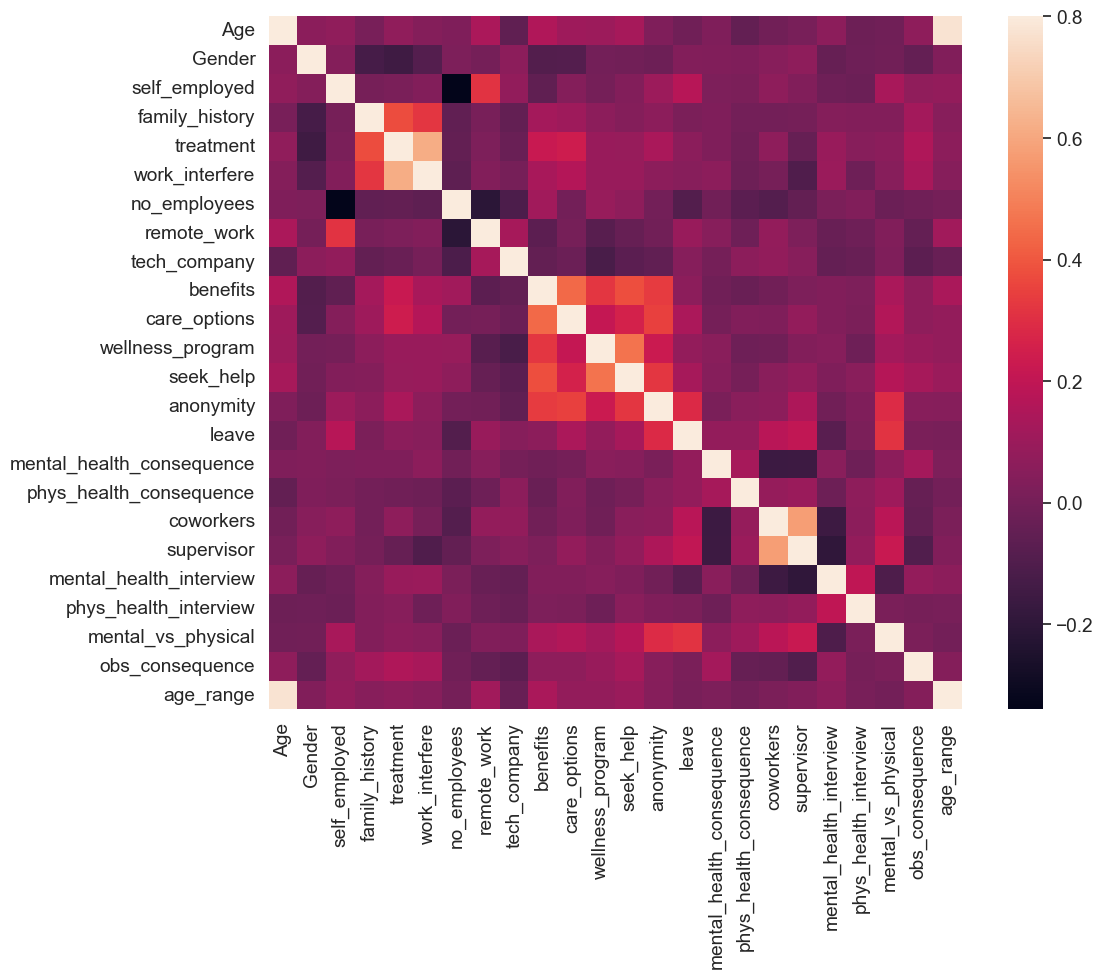

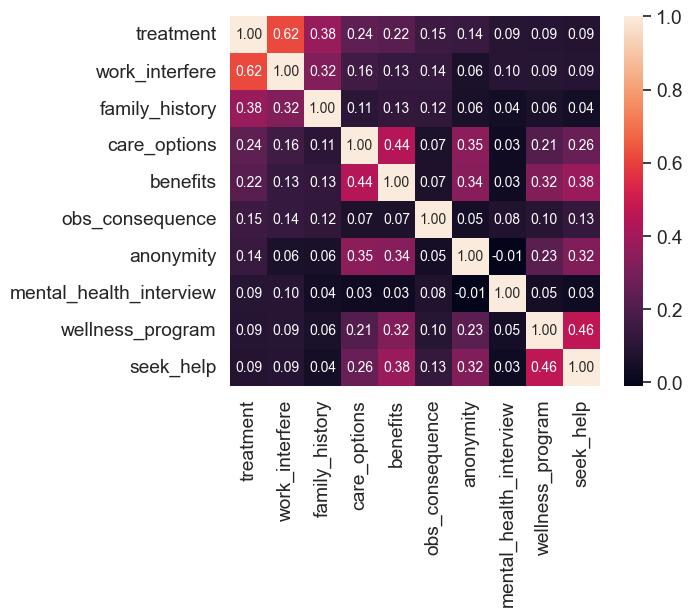

In [64]:
#correlation matrix
corrmat = train_df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);
plt.show()

#treatment correlation matrix
k = 10 #number of variables for heatmap
cols = corrmat.nlargest(k, 'treatment')['treatment'].index
cm = np.corrcoef(train_df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

Implikasi:
* Pemilihan Fitur untuk Model: Fitur-fitur dengan korelasi tinggi dapat dipertimbangkan lebih lanjut untuk model prediksi karena mereka saling berhubungan dengan baik. Sebaliknya, fitur dengan korelasi sangat rendah mungkin bisa diabaikan dalam analisis lebih lanjut.
* Fitur yang Bisa Dipertimbangkan untuk Digabungkan: Fitur dengan korelasi tinggi, seperti treatment dan work_interfere, bisa digabungkan atau dijadikan fitur turunan dalam model untuk meningkatkan akurasi prediksi.
* Korelasi Negatif: Jika ada korelasi negatif yang cukup signifikan, itu bisa menunjukkan relasi yang menarik antara dua fitur yang seharusnya dijelajahi lebih lanjut.

### Some charts to see data relationship

#### Distribution and density by Age

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\2516591640.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df["Age"], bins=24)


Text(0.5, 0, 'Age')

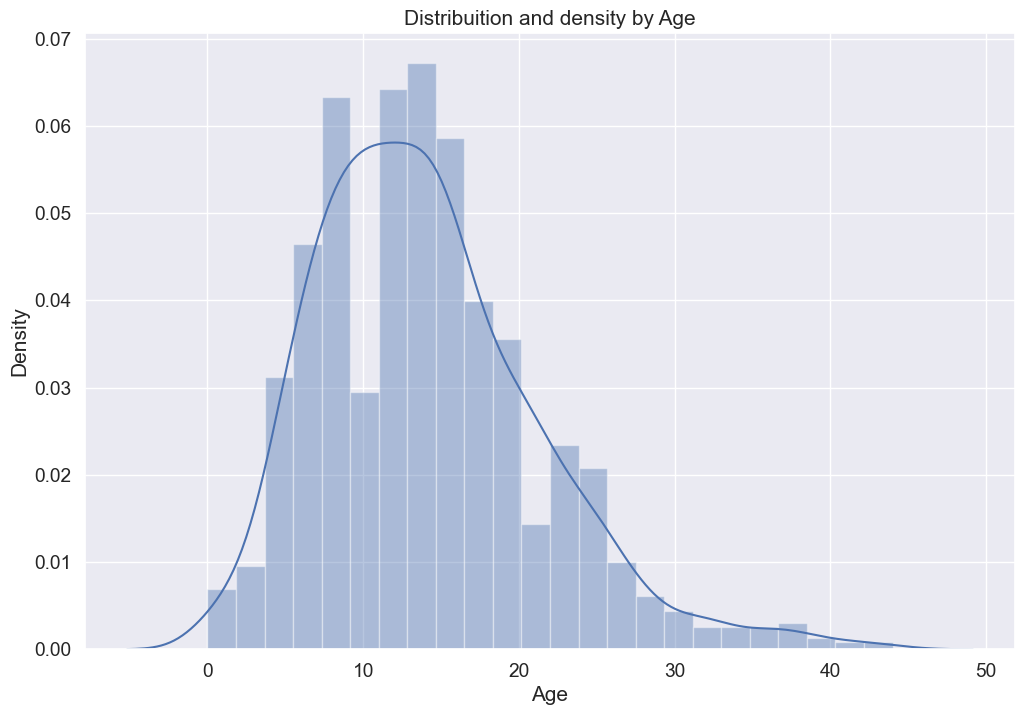

In [65]:
# Distribiution and density by Age
plt.figure(figsize=(12,8))
sns.distplot(train_df["Age"], bins=24)
plt.title("Distribuition and density by Age")
plt.xlabel("Age")

#### Separate by treatment

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fu

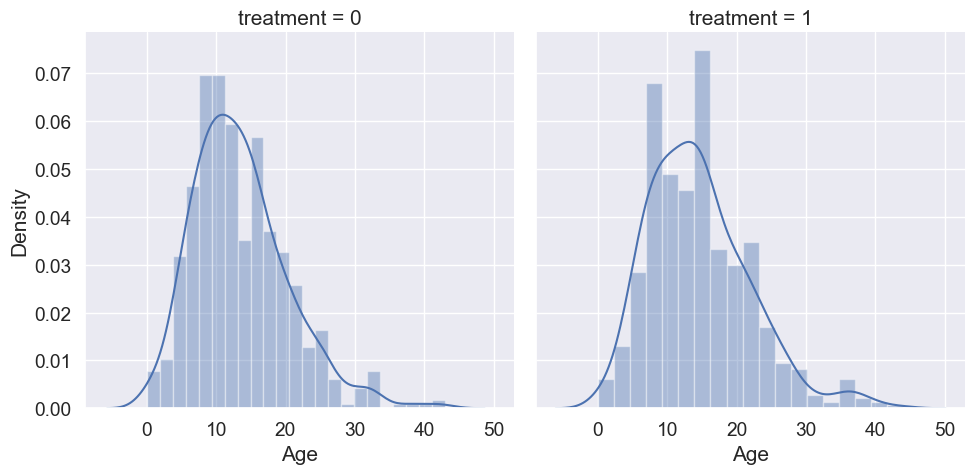

In [66]:
# Separate by treatment or not

g = sns.FacetGrid(train_df, col='treatment', height=5)
g = g.map(sns.distplot, "Age")

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\1998895842.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(["Not Treated", "Treated"])


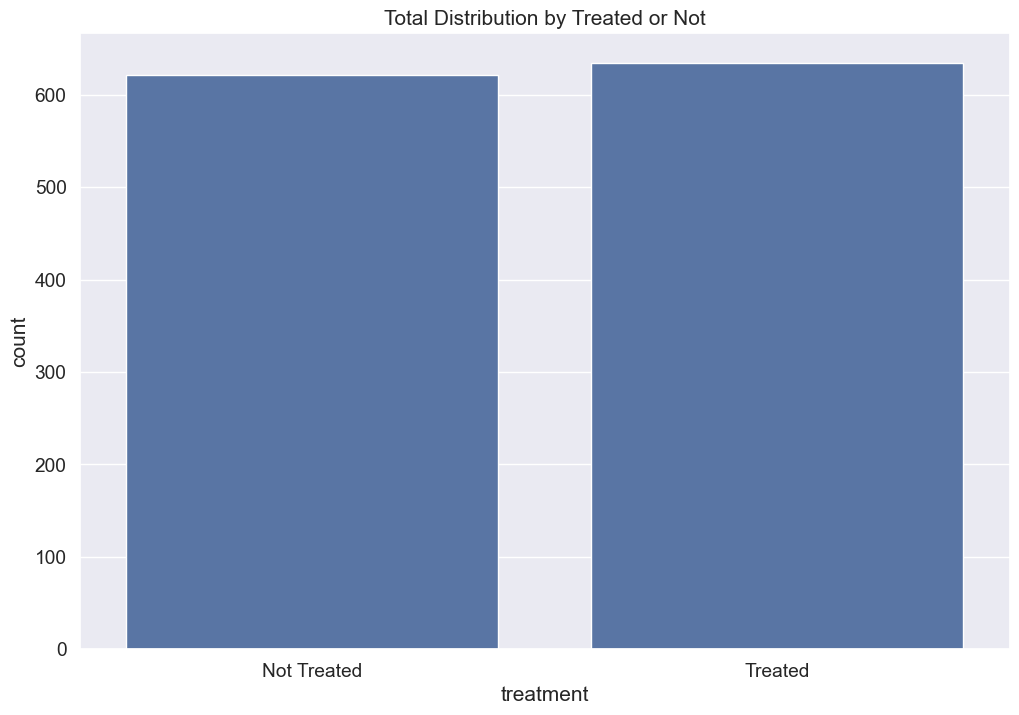

In [67]:
plt.figure(figsize=(12,8))

g = sns.countplot(x="treatment", data=train_df)

g.set_xticklabels(["Not Treated", "Treated"])

plt.title('Total Distribution by Treated or Not')
plt.show()


#### Draw a nested barplot to show probabilities for class and sex

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\1308822600.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(x="age_range", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)


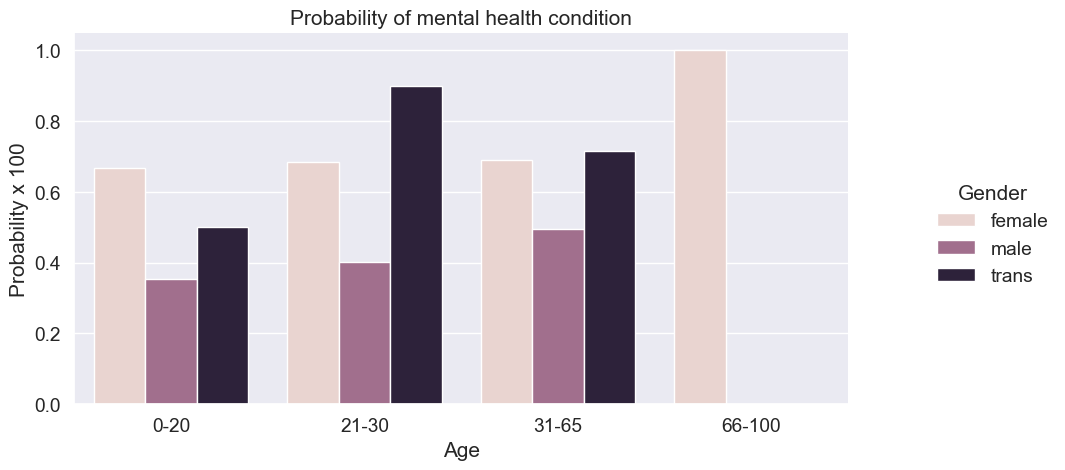

In [68]:
o = labelDict['label_age_range']

# Using catplot instead of factorplot
g = sns.catplot(x="age_range", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)
g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Age')

# Replace legend labels
new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Positioning the legend
g.fig.subplots_adjust(top=0.9, right=0.8)

plt.show()


#### Barplot to show probabilities for family history

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\1780475338.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(x="family_history", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)


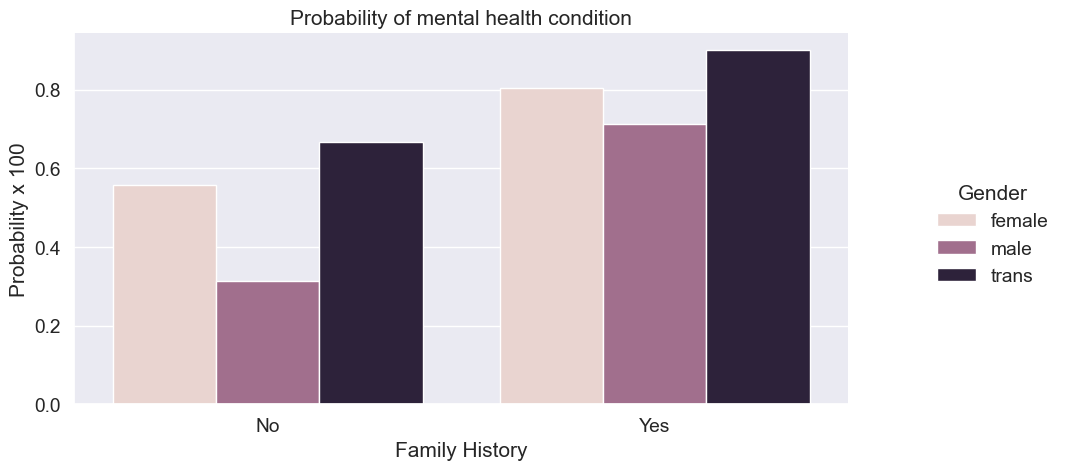

In [69]:
o = labelDict['label_family_history']

# Using catplot instead of factorplot
g = sns.catplot(x="family_history", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)
g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Family History')

# Replace legend labels
new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Positioning the legend
g.fig.subplots_adjust(top=0.9, right=0.8)

plt.show()


#### Barplot to show probabilities for care options

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\1685767560.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(x="care_options", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)


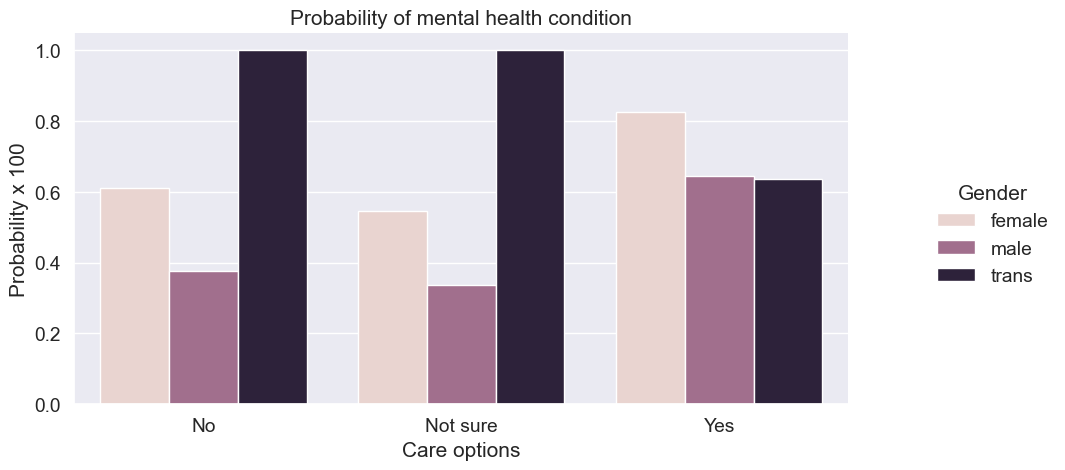

In [70]:
o = labelDict['label_care_options']

# Using catplot instead of factorplot
g = sns.catplot(x="care_options", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)
g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Care options')

# Replace legend labels
new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Positioning the legend
g.fig.subplots_adjust(top=0.9, right=0.8)

plt.show()


#### Barplot to show probabilities for benefits

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\425826267.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(x="care_options", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)


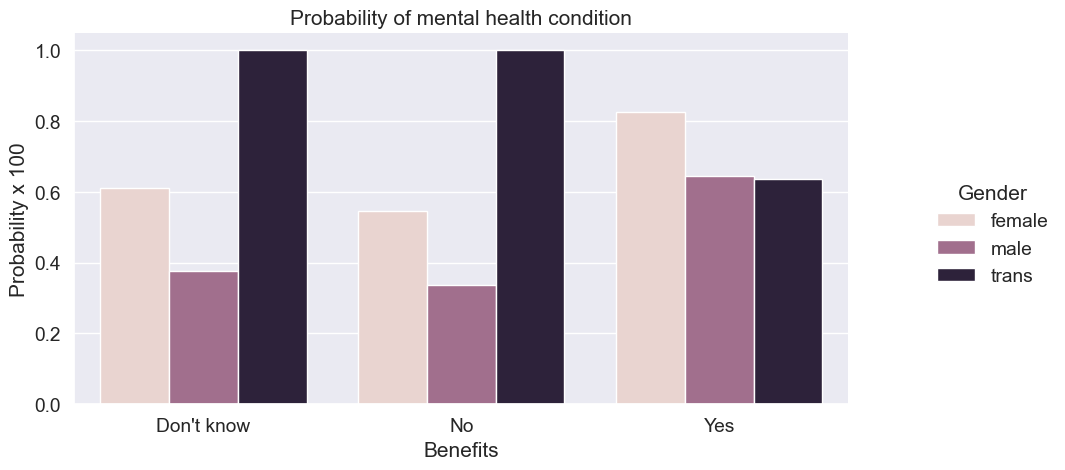

In [71]:
o = labelDict['label_benefits']

# Using catplot instead of factorplot
g = sns.catplot(x="care_options", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)
g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Benefits')

# Replace legend labels
new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Positioning the legend
g.fig.subplots_adjust(top=0.9, right=0.8)

plt.show()


#### Barplot to show probabilities for work interfere

C:\Users\angel\AppData\Local\Temp\ipykernel_29224\1119233335.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(x="work_interfere", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)


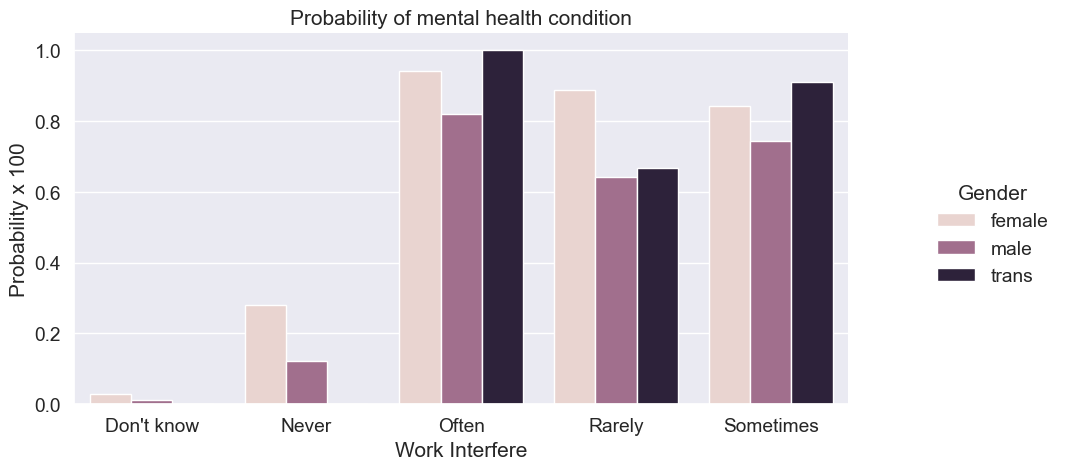

In [72]:
o = labelDict['label_work_interfere']

# Using catplot instead of factorplot
g = sns.catplot(x="work_interfere", y="treatment", hue="Gender", data=train_df, kind="bar", ci=None, height=5, aspect=2, legend_out=True)
g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Work Interfere')

# Replace legend labels
new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Positioning the legend
g.fig.subplots_adjust(top=0.9, right=0.8)

plt.show()


###  Scaling and fitting

In [73]:
# Scaling Age
scaler = MinMaxScaler()
train_df['Age'] = scaler.fit_transform(train_df[['Age']])
train_df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,0.431818,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,0.590909,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,0.318182,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,2
3,0.295455,1,0,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,2
4,0.295455,1,0,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,2


menormalkan kolom Age dalam dataset train_df menggunakan Min-Max Scaling, yang mengubah nilai Age menjadi rentang antara 0 dan 1. Tujuannya adalah untuk membuat data lebih mudah diproses oleh algoritma machine learning, yang sering lebih efisien dengan fitur-fitur yang berada dalam skala yang seragam.

In [74]:
# define X and y
feature_cols = ['Age', 'Gender', 'family_history', 'benefits', 'care_options', 'anonymity', 'leave', 'work_interfere']
X = train_df[feature_cols]
y = train_df.treatment

# split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

# Create dictionaries for final graph
methodDict = {}
f1Dict = {}
rmseDict = ()

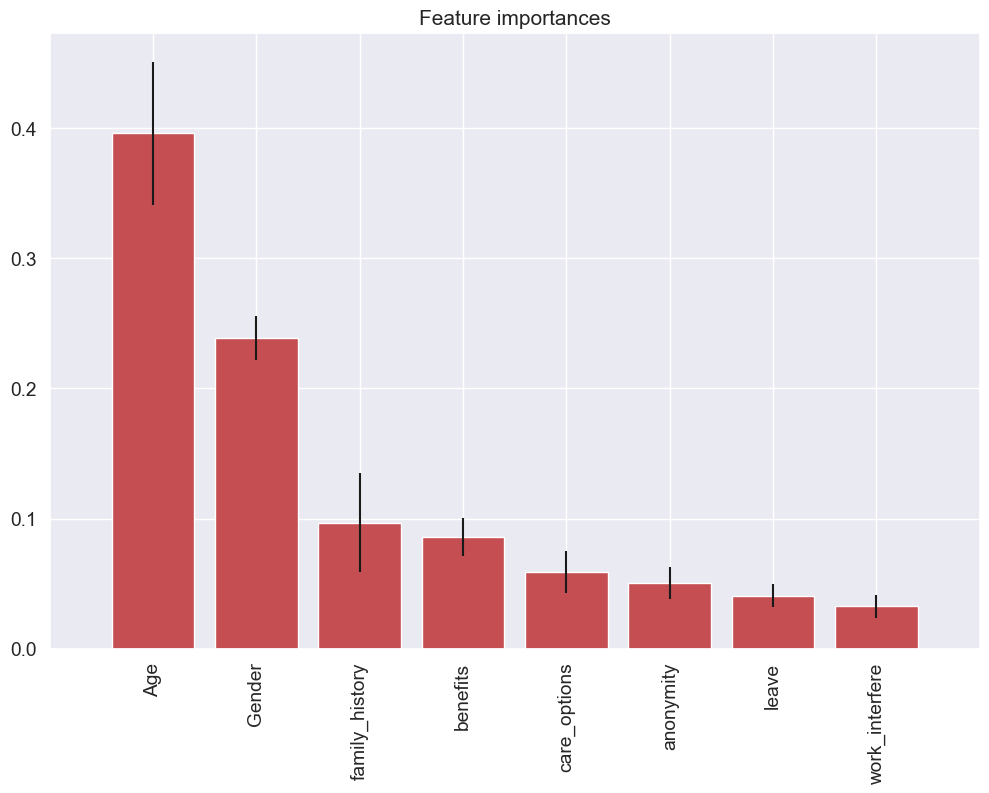

In [75]:
# Build a forest and compute the feature importances
forest = ExtraTreesClassifier(n_estimators=250,
                              random_state=0)

forest.fit(X, y)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

labels = []
for f in range(X.shape[1]):
    labels.append(feature_cols[f])      
    
# Plot the feature importances of the forest
plt.figure(figsize=(12,8))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), labels, rotation='vertical')
plt.xlim([-1, X.shape[1]])
plt.show()


berdasarkan chart berikut ini maka kita mengurangi dari yang awalnya 27 fitur menjadi hanya 7 fitur saja yang digunakan. karena 7 fitur ini yang paling berpengaruh terhadap hasilnya

### Tuning

In [76]:
from sklearn.preprocessing import binarize
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_score

def evalClassModel(model, X_test, y_test, y_pred_class, plot=False):
    print('Accuracy:', metrics.accuracy_score(y_test, y_pred_class))
    print('Null accuracy:\n', y_test.value_counts())
    print('Percentage of ones:', y_test.mean())
    print('Percentage of zeros:', 1 - y_test.mean())
    
    # Comparing the true and predicted response values
    print('True:', y_test.values[0:25])
    print('Pred:', y_pred_class[0:25])
    
    # Confusion matrix
    confusion = metrics.confusion_matrix(y_test, y_pred_class)
    TP = confusion[1, 1]
    TN = confusion[0, 0]
    FP = confusion[0, 1]
    FN = confusion[1, 0]
    
    # Visualize Confusion Matrix
    sns.heatmap(confusion, annot=True, fmt="d")
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Metrics computed from a confusion matrix
    accuracy = metrics.accuracy_score(y_test, y_pred_class)
    print('Classification Accuracy:', accuracy)
    print('Classification Error:', 1 - accuracy)
    
    false_positive_rate = FP / float(TN + FP)
    print('False Positive Rate:', false_positive_rate)
    
    print('Precision:', metrics.precision_score(y_test, y_pred_class))
    
    # F1 Score
    print('F1 Score:', metrics.f1_score(y_test, y_pred_class))
    
    # AUC Score
    print('AUC Score:', metrics.roc_auc_score(y_test, y_pred_class))
    
    # Cross-validated AUC
    print('Cross-validated AUC:', cross_val_score(model, X_test, y_test, cv=10, scoring='roc_auc').mean())
    
    # Adjusting the classification threshold
    print('First 10 predicted responses:\n', model.predict(X_test)[0:10])
    print('First 10 predicted probabilities of class members:\n', model.predict_proba(X_test)[0:10])
    print('First 10 predicted probabilities for class 1:\n', model.predict_proba(X_test)[:, 1][0:10])
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    if plot:
        plt.hist(y_pred_prob, bins=8)
        plt.xlim(0, 1)
        plt.title('Histogram of predicted probabilities')
        plt.xlabel('Predicted probability of treatment')
        plt.ylabel('Frequency')
        plt.show()
    
    # Predict treatment if the predicted probability is greater than 0.3
    y_pred_prob = y_pred_prob.reshape(-1, 1)
    y_pred_class = binarize(y_pred_prob, threshold=0.3)  # Fix here: threshold as keyword argument
    
    print('First 10 predicted probabilities:\n', y_pred_prob[0:10])
    
    # ROC Curves and Area Under the Curve (AUC)
    roc_auc = metrics.roc_auc_score(y_test, y_pred_prob)
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)
    
    if plot:
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.0])
        plt.title('ROC curve for treatment classifier')
        plt.xlabel('False Positive Rate (1 - Specificity)')
        plt.ylabel('True Positive Rate (Sensitivity)')
        plt.legend(loc="lower right")
        plt.show()

    # Threshold evaluation
    def evaluate_threshold(threshold):
        print('Specificity for ' + str(threshold) + ' :', 1 - fpr[thresholds > threshold][-1])

    predict_mine = np.where(y_pred_prob > 0.50, 1, 0)
    confusion = metrics.confusion_matrix(y_test, predict_mine)
    print(confusion)
    
    return accuracy


Fungsi ini menyediakan evaluasi menyeluruh dari model klasifikasi, dengan berbagai metrik dan visualisasi yang penting seperti:
* Akurasi, precision, recall, F1 score.
* AUC (Area Under the Curve) dan ROC Curve.
* Confusion matrix.
* Evaluasi menggunakan threshold (untuk melihat performa model pada berbagai ambang batas probabilitas).  

Output:
* Akurasi: Mencetak dan mengembalikan akurasi model.
* Metrik Evaluasi Lain: Presisi, F1 Score, False Positive Rate, dll.
* Visualisasi: Confusion Matrix dan ROC Curve (jika plot=True).

#### Tuning with cross validation score

In [77]:
##########################################
# Tuning with cross validation score
##########################################
def tuningCV(knn):
    
    # search for an optimal value of K for KNN
    k_range = list(range(1, 31))
    k_scores = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
        k_scores.append(scores.mean())
    print(k_scores)
    # plot the value of K for KNN (x-axis) versus the cross-validated accuracy (y-axis)
    plt.plot(k_range, k_scores)
    plt.xlabel('Value of K for KNN')
    plt.ylabel('Cross-Validated Accuracy')
    plt.show()

Fungsi ini digunakan untuk mengoptimalkan parameter K pada model KNN dengan menggunakan cross-validation. Dengan memplot hasilnya, kita bisa melihat nilai K yang memberikan akurasi terbaik, yang bisa digunakan untuk mengatur parameter model. Hal ini penting untuk mendapatkan model yang lebih baik dengan memilih nilai K yang tepat.

#### Tuning with GridSearchCV

In [78]:
def tuningGridSerach(knn):
    #More efficient parameter tuning using GridSearchCV
    # define the parameter values that should be searched
    k_range = list(range(1, 31))
    print(k_range)
    
    param_grid = dict(n_neighbors=k_range)
    print(param_grid)
    
    # instantiate the grid
    grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')

    # fit the grid with data
    grid.fit(X, y)
    
    # view the complete results (list of named tuples)
    grid.grid_scores_
    
    # examine the first tuple
    print(grid.grid_scores_[0].parameters)
    print(grid.grid_scores_[0].cv_validation_scores)
    print(grid.grid_scores_[0].mean_validation_score)
    
    # create a list of the mean scores only
    grid_mean_scores = [result.mean_validation_score for result in grid.grid_scores_]
    print(grid_mean_scores)
    
    # plot the results
    plt.plot(k_range, grid_mean_scores)
    plt.xlabel('Value of K for KNN')
    plt.ylabel('Cross-Validated Accuracy')
    plt.show()
    
    # examine the best model
    print('GridSearch best score', grid.best_score_)
    print('GridSearch best params', grid.best_params_)
    print('GridSearch best estimator', grid.best_estimator_)

Fungsi ini bertujuan untuk melakukan pencarian parameter terbaik (dalam hal ini, nilai K untuk KNN) secara otomatis dengan menggunakan GridSearchCV. Ini memungkinkan pencarian parameter secara menyeluruh dan efisien dengan cross-validation, sehingga dapat memperoleh nilai parameter yang memberikan hasil terbaik untuk model. Selain itu, fungsi ini juga menggambarkan grafik yang menunjukkan akurasi yang dicapai dengan berbagai nilai K.

Dengan menggunakan GridSearchCV, pencarian parameter menjadi lebih otomatis dan lebih cepat, serta mengurangi kemungkinan overfitting atau underfitting karena validasi silang yang dilakukan pada setiap kombinasi parameter.

#### Tuning with RandomizedSearchCV

In [79]:
def tuningRandomizedSearchCV(model, param_dist):
    #Searching multiple parameters simultaneously
    # n_iter controls the number of searches
    rand = RandomizedSearchCV(model, param_dist, cv=10, scoring='accuracy', n_iter=10, random_state=5)
    rand.fit(X, y)
    rand.grid_scores_
    
    # examine the best model
    print('Rand. Best Score: ', rand.best_score_)
    print('Rand. Best Params: ', rand.best_params_)
    
    # run RandomizedSearchCV 20 times (with n_iter=10) and record the best score
    best_scores = []
    for _ in range(20):
        rand = RandomizedSearchCV(model, param_dist, cv=10, scoring='accuracy', n_iter=10)
        rand.fit(X, y)
        best_scores.append(round(rand.best_score_, 3))
    print(best_scores)

Fungsi tuningRandomizedSearchCV digunakan untuk melakukan pencarian parameter model secara acak menggunakan RandomizedSearchCV. Pencarian acak memungkinkan untuk menguji sejumlah besar kombinasi parameter dalam waktu yang lebih singkat dibandingkan dengan pencarian grid secara menyeluruh.

#### Tuning with searching multiple parameters simultaneously

In [80]:
from sklearn.model_selection import GridSearchCV

def tuningMultParam(knn, X, y):
    # Searching multiple parameters simultaneously
    k_range = list(range(1, 31))
    weight_options = ['uniform', 'distance']

    # Create a parameter grid: map the parameter names to the values that should be searched
    param_grid = dict(n_neighbors=k_range, weights=weight_options)
    print(param_grid) 

    # Instantiate and fit the grid search
    grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
    grid.fit(X, y) 
    
    # View the complete results (using cv_results_)
    print(grid.cv_results_)
    
    # Examine the best model
    print('Multiparam. Best Score: ', grid.best_score_)
    print('Multiparam. Best Params: ', grid.best_params_)


Fungsi ini digunakan untuk mencari parameter terbaik untuk model KNN dengan menggunakan pencarian grid yang lebih efisien dan lebih komprehensif. Ini memungkinkan kita untuk menguji kombinasi parameter secara bersamaan dan menemukan parameter yang menghasilkan kinerja terbaik dengan menggunakan cross-validation.

#### Evaluating models

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def logisticRegression(X_train, y_train, X_test, y_test, methodDict):
    # Train a logistic regression model on the training set
    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = logreg.predict(X_test)
    
    print('########### Logistic Regression ###############')
    
    # Call evalClassModel with correct arguments
    accuracy_score = evalClassModel(logreg, X_test, y_test, y_pred_class, True)
    
    # Data for final graph
    methodDict['Log. Regres.'] = accuracy_score * 100
    f1Dict['Log. Regres.'] = f1_score(y_test, y_pred_class)
    return methodDict


########### Logistic Regression ###############
Accuracy: 0.7936507936507936
Null accuracy:
 treatment
0    191
1    187
Name: count, dtype: int64
Percentage of ones: 0.4947089947089947
Percentage of zeros: 0.5052910052910053
True: [0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0]
Pred: [1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0]


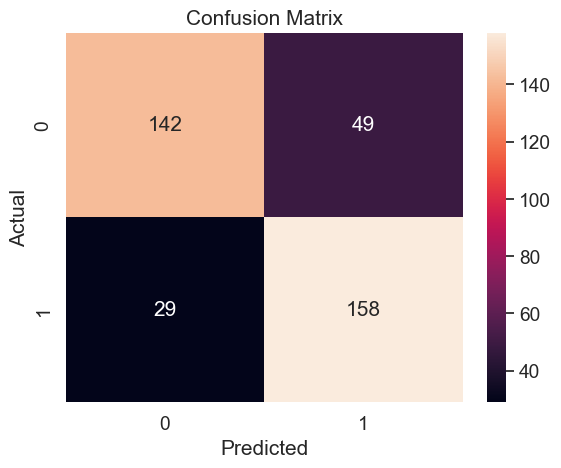

Classification Accuracy: 0.7936507936507936
Classification Error: 0.2063492063492064
False Positive Rate: 0.25654450261780104
Precision: 0.7632850241545893
F1 Score: 0.8020304568527918
AUC Score: 0.794187641739228
Cross-validated AUC: 0.868014004309018
First 10 predicted responses:
 [1 0 0 0 1 1 0 1 0 1]
First 10 predicted probabilities of class members:
 [[0.09192784 0.90807216]
 [0.95998457 0.04001543]
 [0.96552072 0.03447928]
 [0.78739197 0.21260803]
 [0.38947126 0.61052874]
 [0.05256967 0.94743033]
 [0.75023269 0.24976731]
 [0.19037376 0.80962624]
 [0.61623206 0.38376794]
 [0.4769296  0.5230704 ]]
First 10 predicted probabilities for class 1:
 [0.90807216 0.04001543 0.03447928 0.21260803 0.61052874 0.94743033
 0.24976731 0.80962624 0.38376794 0.5230704 ]


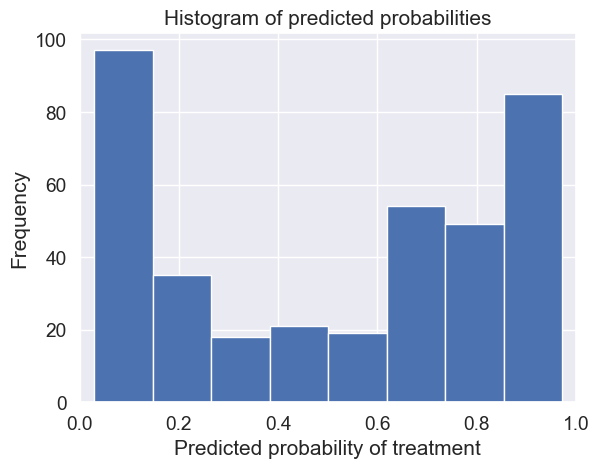

First 10 predicted probabilities:
 [[0.90807216]
 [0.04001543]
 [0.03447928]
 [0.21260803]
 [0.61052874]
 [0.94743033]
 [0.24976731]
 [0.80962624]
 [0.38376794]
 [0.5230704 ]]


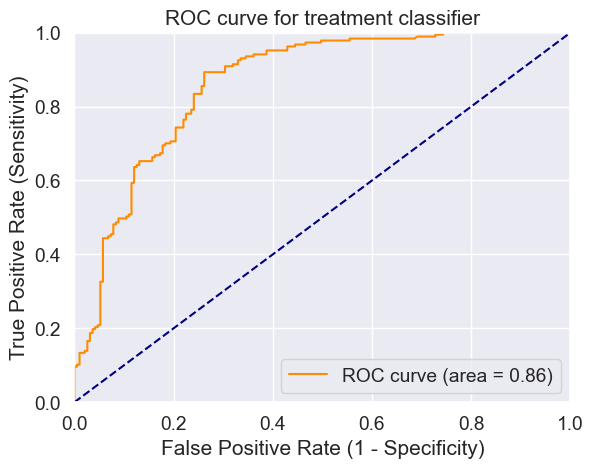

[[142  49]
 [ 29 158]]


{'Log. Regres.': 79.36507936507937}

In [82]:
logisticRegression(X_train, y_train, X_test, y_test, methodDict)


#### KNeighbors Classifier

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

def Knn(X_train, y_train, X_test, y_test, methodDict):
    # Calculating the best parameters
    knn = KNeighborsClassifier(n_neighbors=5)
    
    # Define the parameter values that should be searched
    k_range = list(range(1, 31))
    weight_options = ['uniform', 'distance']
    
    # Specify "parameter distributions" rather than a "parameter grid"
    param_dist = dict(n_neighbors=k_range, weights=weight_options)
    
    # Perform RandomizedSearchCV
    tuningRandomizedSearchCV(knn, param_dist, X_train, y_train)
    
    # Train a KNeighborsClassifier model on the training set with the best parameters
    knn = KNeighborsClassifier(n_neighbors=27, weights='uniform')  # Adjust these based on RandomizedSearchCV result
    knn.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = knn.predict(X_test)
    
    print('########### KNeighborsClassifier ###############')
    
    accuracy_score = evalClassModel(knn, X_test, y_test, y_pred_class, True)

    # Data for final graph
    methodDict['KNN'] = accuracy_score * 100
    f1Dict['KNN'] = f1_score(y_test, y_pred_class)
    return methodDict

def tuningRandomizedSearchCV(knn, param_dist, X_train, y_train):
    # Instantiate and fit RandomizedSearchCV
    random_search = RandomizedSearchCV(knn, param_distributions=param_dist, n_iter=10, cv=10, scoring='accuracy', random_state=42)
    random_search.fit(X_train, y_train)

    # View the complete results using cv_results_
    print(random_search.cv_results_)

    # Examine the best model
    print('RandomizedSearchCV Best Score: ', random_search.best_score_)
    print('RandomizedSearchCV Best Params: ', random_search.best_params_)


{'mean_fit_time': array([0.00406599, 0.00382898, 0.0044147 , 0.00313904, 0.00446973,
       0.00340328, 0.0039655 , 0.00452096, 0.00413094, 0.00409906]), 'std_fit_time': array([0.00049048, 0.00028091, 0.00124023, 0.00084322, 0.00165217,
       0.00053782, 0.00035686, 0.00054031, 0.00060926, 0.0003692 ]), 'mean_score_time': array([0.00689206, 0.00377786, 0.0088758 , 0.00376148, 0.00384433,
       0.0071641 , 0.00405726, 0.00894527, 0.00779891, 0.00534039]), 'std_score_time': array([0.00063262, 0.00069859, 0.00309833, 0.00112016, 0.0011775 ,
       0.00125786, 0.00015567, 0.00109274, 0.00064808, 0.00062465]), 'param_weights': masked_array(data=['uniform', 'distance', 'uniform', 'distance',
                   'distance', 'uniform', 'distance', 'uniform',
                   'uniform', 'distance'],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value='?',
            dtype=object), 'param_n_neighbors': masked_array(da

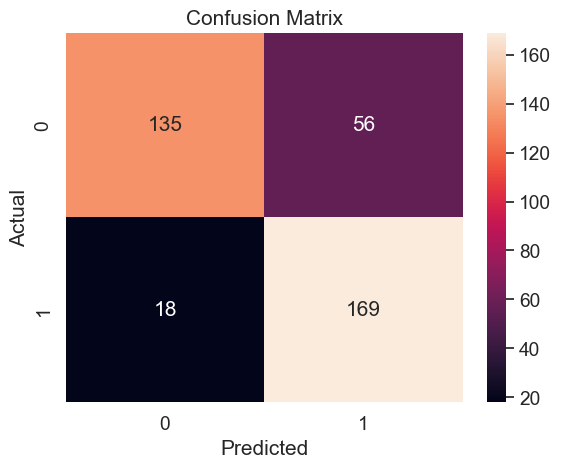

Classification Accuracy: 0.8042328042328042
Classification Error: 0.1957671957671958
False Positive Rate: 0.2931937172774869
Precision: 0.7511111111111111
F1 Score: 0.8203883495145631
AUC Score: 0.8052747991152673
Cross-validated AUC: 0.8664639119729147
First 10 predicted responses:
 [1 0 0 0 1 1 0 1 1 1]
First 10 predicted probabilities of class members:
 [[0.33333333 0.66666667]
 [1.         0.        ]
 [1.         0.        ]
 [0.66666667 0.33333333]
 [0.37037037 0.62962963]
 [0.03703704 0.96296296]
 [0.59259259 0.40740741]
 [0.37037037 0.62962963]
 [0.33333333 0.66666667]
 [0.33333333 0.66666667]]
First 10 predicted probabilities for class 1:
 [0.66666667 0.         0.         0.33333333 0.62962963 0.96296296
 0.40740741 0.62962963 0.66666667 0.66666667]


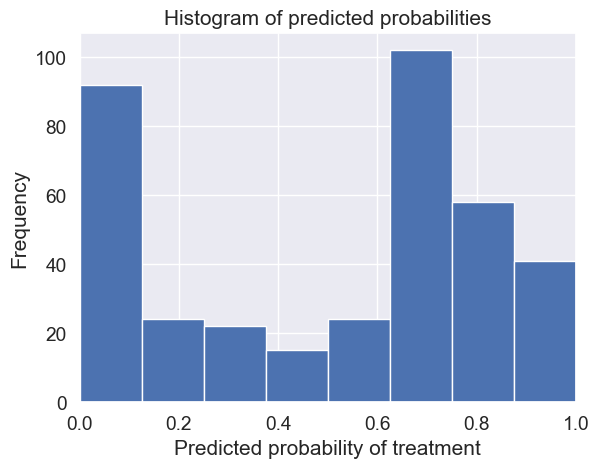

First 10 predicted probabilities:
 [[0.66666667]
 [0.        ]
 [0.        ]
 [0.33333333]
 [0.62962963]
 [0.96296296]
 [0.40740741]
 [0.62962963]
 [0.66666667]
 [0.66666667]]


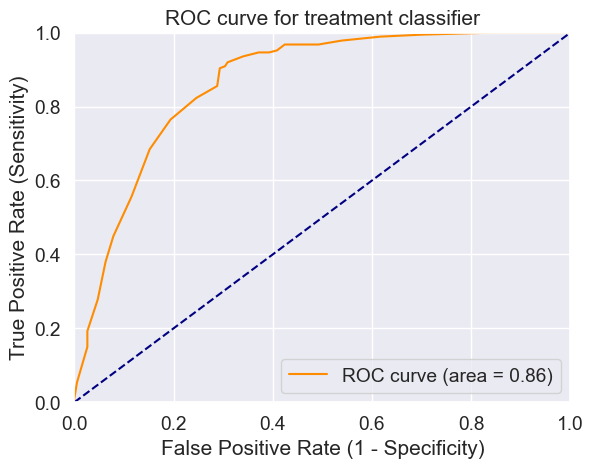

[[135  56]
 [ 18 169]]


{'Log. Regres.': 79.36507936507937, 'KNN': 80.42328042328042}

In [84]:
Knn(X_train, y_train, X_test, y_test, methodDict)

#### Decision Tree classifier

In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import binarize

def treeClassifier(X_train, y_train, X_test, y_test, feature_cols, methodDict):
    # Calculating the best parameters
    tree = DecisionTreeClassifier()
    featuresSize = len(feature_cols)
    
    param_dist = {"max_depth": [3, None],
                  "max_features": randint(1, featuresSize),
                  "min_samples_split": randint(2, 9),
                  "min_samples_leaf": randint(1, 9),
                  "criterion": ["gini", "entropy"]}
    
    # Perform RandomizedSearchCV
    tuningRandomizedSearchCV(tree, param_dist, X_train, y_train)
    
    # Train a decision tree model on the training set with the best parameters
    tree = DecisionTreeClassifier(max_depth=3, min_samples_split=8, max_features=6, criterion='entropy', min_samples_leaf=7)
    tree.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = tree.predict(X_test)
    
    print('########### Tree classifier ###############')
    
    accuracy_score = evalClassModel(tree, X_test, y_test, y_pred_class, True)

    # Data for final graph
    methodDict['Tree clas.'] = accuracy_score * 100
    f1Dict['Tree clas.'] = f1_score(y_test, y_pred_class)
    return methodDict

def tuningRandomizedSearchCV(model, param_dist, X_train, y_train):
    # Instantiate and fit RandomizedSearchCV
    random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=10, scoring='accuracy', random_state=42)
    random_search.fit(X_train, y_train)

    # View the complete results using cv_results_
    print(random_search.cv_results_)

    # Examine the best model
    print('RandomizedSearchCV Best Score: ', random_search.best_score_)
    print('RandomizedSearchCV Best Params: ', random_search.best_params_)


{'mean_fit_time': array([0.0038265 , 0.00360918, 0.003001  , 0.0037451 , 0.00494387,
       0.00517311, 0.00521929, 0.00358222, 0.00482283, 0.00472119]), 'std_fit_time': array([0.00081645, 0.00056194, 0.00045509, 0.00057534, 0.00075893,
       0.00092466, 0.00098117, 0.00058779, 0.00088541, 0.0008701 ]), 'mean_score_time': array([0.00254564, 0.00237427, 0.00202787, 0.00291243, 0.00366237,
       0.00305727, 0.00276845, 0.00223777, 0.00313344, 0.00220332]), 'std_score_time': array([0.00050169, 0.00045662, 0.00066817, 0.00060735, 0.00084008,
       0.00118054, 0.00057266, 0.00049948, 0.00098722, 0.00038802]), 'param_criterion': masked_array(data=['gini', 'entropy', 'gini', 'entropy', 'entropy',
                   'entropy', 'entropy', 'gini', 'entropy', 'entropy'],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value='?',
            dtype=object), 'param_max_depth': masked_array(data=[None, 3, 3, None, None, None,

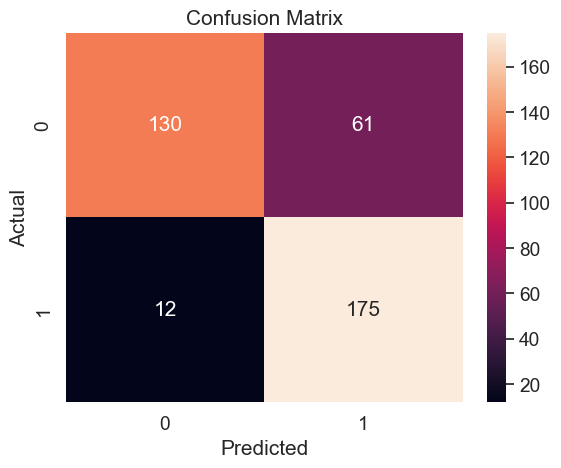

Classification Accuracy: 0.8068783068783069
Classification Error: 0.19312169312169314
False Positive Rate: 0.3193717277486911
Precision: 0.7415254237288136
F1 Score: 0.8274231678486997
AUC Score: 0.8082285746283282
Cross-validated AUC: 0.8652204524469068
First 10 predicted responses:
 [1 0 0 0 1 1 0 1 1 1]
First 10 predicted probabilities of class members:
 [[0.18823529 0.81176471]
 [0.97959184 0.02040816]
 [1.         0.        ]
 [0.8778626  0.1221374 ]
 [0.36097561 0.63902439]
 [0.05172414 0.94827586]
 [0.8778626  0.1221374 ]
 [0.11320755 0.88679245]
 [0.36097561 0.63902439]
 [0.36097561 0.63902439]]
First 10 predicted probabilities for class 1:
 [0.81176471 0.02040816 0.         0.1221374  0.63902439 0.94827586
 0.1221374  0.88679245 0.63902439 0.63902439]


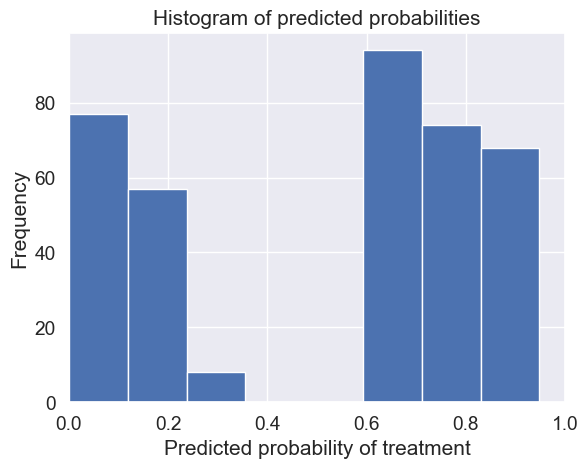

First 10 predicted probabilities:
 [[0.81176471]
 [0.02040816]
 [0.        ]
 [0.1221374 ]
 [0.63902439]
 [0.94827586]
 [0.1221374 ]
 [0.88679245]
 [0.63902439]
 [0.63902439]]


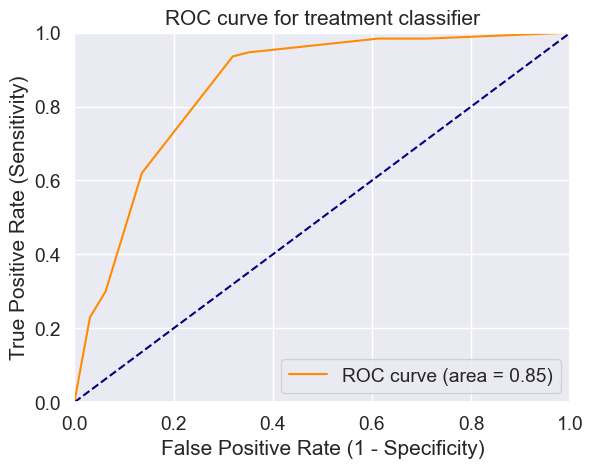

[[130  61]
 [ 12 175]]


{'Log. Regres.': 79.36507936507937,
 'KNN': 80.42328042328042,
 'Tree clas.': 80.68783068783068}

In [86]:
treeClassifier(X_train, y_train, X_test, y_test, feature_cols, methodDict)

#### Random Forests

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import binarize

def randomForest(X_train, y_train, X_test, y_test, feature_cols, methodDict):
    # Calculating the best parameters
    forest = RandomForestClassifier(n_estimators=20)
    featuresSize = len(feature_cols)  # Using len() instead of __len__()

    param_dist = {
        "max_depth": [3, None],
        "max_features": randint(1, featuresSize),
        "min_samples_split": randint(2, 9),
        "min_samples_leaf": randint(1, 9),
        "criterion": ["gini", "entropy"]
    }

    # Perform RandomizedSearchCV
    tuningRandomizedSearchCV(forest, param_dist, X_train, y_train)
    
    # Train the best RandomForestClassifier model
    forest = RandomForestClassifier(max_depth=None, min_samples_leaf=8, min_samples_split=2, 
                                    n_estimators=20, random_state=1)
    my_forest = forest.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = my_forest.predict(X_test)
    
    print('########### Random Forests ###############')
    
    # Call evalClassModel correctly
    accuracy_score = evalClassModel(my_forest, X_test, y_test, y_pred_class, True)
    # Data for final graph
    methodDict['R. Forest'] = accuracy_score * 100
    f1Dict['R. Forest'] = f1_score(y_test, y_pred_class)
    return methodDict

def tuningRandomizedSearchCV(model, param_dist, X_train, y_train):
    # Instantiate and fit RandomizedSearchCV
    random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=10, 
                                       scoring='accuracy', random_state=42)
    random_search.fit(X_train, y_train)

    # View the complete results using cv_results_
    print(random_search.cv_results_)

    # Examine the best model
    print('RandomizedSearchCV Best Score: ', random_search.best_score_)
    print('RandomizedSearchCV Best Params: ', random_search.best_params_)


{'mean_fit_time': array([0.04453592, 0.03639567, 0.04299841, 0.04618063, 0.05335789,
       0.0437103 , 0.06371286, 0.05123811, 0.06133218, 0.06121838]), 'std_fit_time': array([0.00825571, 0.00593815, 0.02244198, 0.00741038, 0.0158756 ,
       0.00525268, 0.00937711, 0.00493747, 0.00663107, 0.00811568]), 'mean_score_time': array([0.00493269, 0.00382838, 0.00382502, 0.00444317, 0.00644147,
       0.00437632, 0.00628281, 0.00548835, 0.00642452, 0.00585351]), 'std_score_time': array([0.00140928, 0.00127649, 0.00123778, 0.00130151, 0.00358679,
       0.00141121, 0.00167532, 0.00065653, 0.00164642, 0.00137897]), 'param_criterion': masked_array(data=['gini', 'entropy', 'gini', 'entropy', 'entropy',
                   'entropy', 'entropy', 'gini', 'entropy', 'entropy'],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value='?',
            dtype=object), 'param_max_depth': masked_array(data=[None, 3, 3, None, None, None,

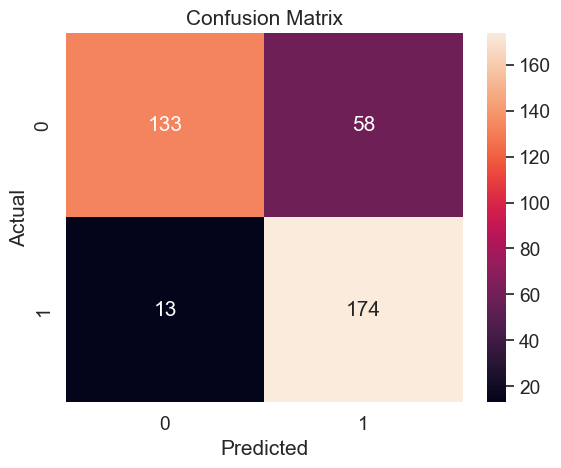

Classification Accuracy: 0.8121693121693122
Classification Error: 0.1878306878306878
False Positive Rate: 0.3036649214659686
Precision: 0.75
F1 Score: 0.8305489260143198
AUC Score: 0.8134081809782457
Cross-validated AUC: 0.8911849799938443
First 10 predicted responses:
 [1 0 0 0 1 1 0 1 1 1]
First 10 predicted probabilities of class members:
 [[0.2555794  0.7444206 ]
 [0.95069083 0.04930917]
 [0.93851009 0.06148991]
 [0.87096597 0.12903403]
 [0.40653554 0.59346446]
 [0.17282958 0.82717042]
 [0.89450448 0.10549552]
 [0.4065912  0.5934088 ]
 [0.20540631 0.79459369]
 [0.19337644 0.80662356]]
First 10 predicted probabilities for class 1:
 [0.7444206  0.04930917 0.06148991 0.12903403 0.59346446 0.82717042
 0.10549552 0.5934088  0.79459369 0.80662356]


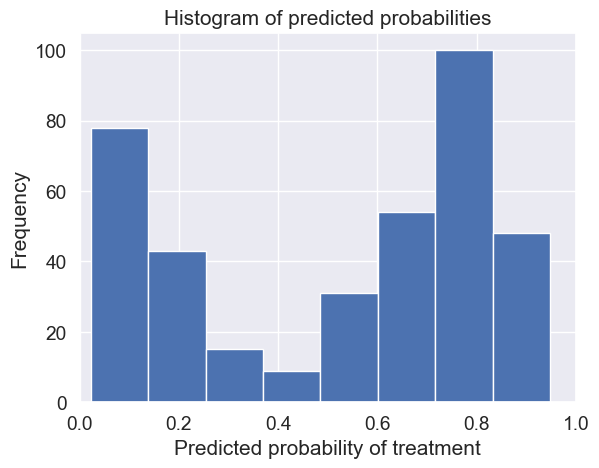

First 10 predicted probabilities:
 [[0.7444206 ]
 [0.04930917]
 [0.06148991]
 [0.12903403]
 [0.59346446]
 [0.82717042]
 [0.10549552]
 [0.5934088 ]
 [0.79459369]
 [0.80662356]]


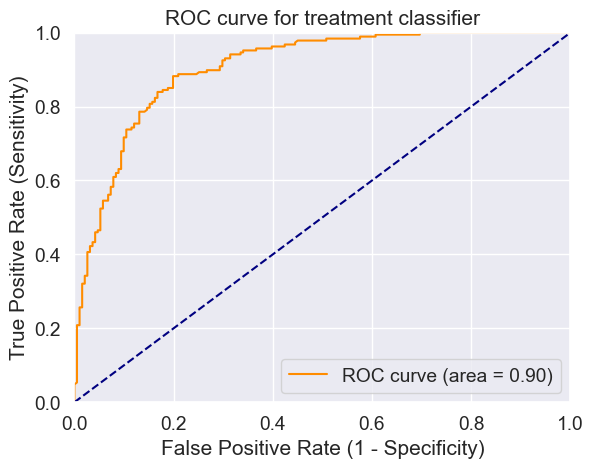

[[133  58]
 [ 13 174]]


{'Log. Regres.': 79.36507936507937,
 'KNN': 80.42328042328042,
 'Tree clas.': 80.68783068783068,
 'R. Forest': 81.21693121693121}

In [88]:
randomForest(X_train, y_train, X_test, y_test, feature_cols, methodDict)

#### Bagging

In [89]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import binarize

def bagging(X_train, y_train, X_test, y_test, methodDict):
    # Building and fitting the bagging classifier
    bag = BaggingClassifier(DecisionTreeClassifier(), max_samples=1.0, max_features=1.0, bootstrap_features=False)
    bag.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = bag.predict(X_test)
    
    print('########### Bagging ###############')
    
    # Evaluate the model
    accuracy_score = evalClassModel(bag, X_test, y_test, y_pred_class, True)

    # Store results for final graph
    methodDict['Bagging'] = accuracy_score * 100
    f1Dict['Bagging'] = f1_score(y_test, y_pred_class)
    return methodDict


########### Bagging ###############
Accuracy: 0.7936507936507936
Null accuracy:
 treatment
0    191
1    187
Name: count, dtype: int64
Percentage of ones: 0.4947089947089947
Percentage of zeros: 0.5052910052910053
True: [0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0]
Pred: [1 0 0 0 0 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0]


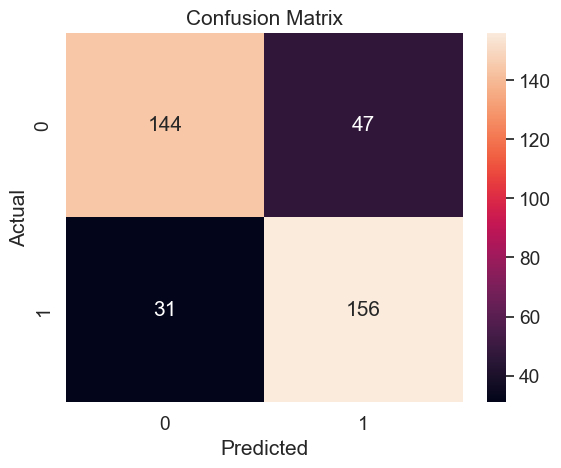

Classification Accuracy: 0.7936507936507936
Classification Error: 0.2063492063492064
False Positive Rate: 0.24607329842931938
Precision: 0.7684729064039408
F1 Score: 0.8
AUC Score: 0.794075650250581
Cross-validated AUC: 0.8599807633117882
First 10 predicted responses:
 [1 0 0 0 0 1 0 0 1 1]
First 10 predicted probabilities of class members:
 [[0.07333333 0.92666667]
 [1.         0.        ]
 [1.         0.        ]
 [0.8        0.2       ]
 [0.8        0.2       ]
 [0.05       0.95      ]
 [0.9        0.1       ]
 [0.6        0.4       ]
 [0.1        0.9       ]
 [0.2        0.8       ]]
First 10 predicted probabilities for class 1:
 [0.92666667 0.         0.         0.2        0.2        0.95
 0.1        0.4        0.9        0.8       ]


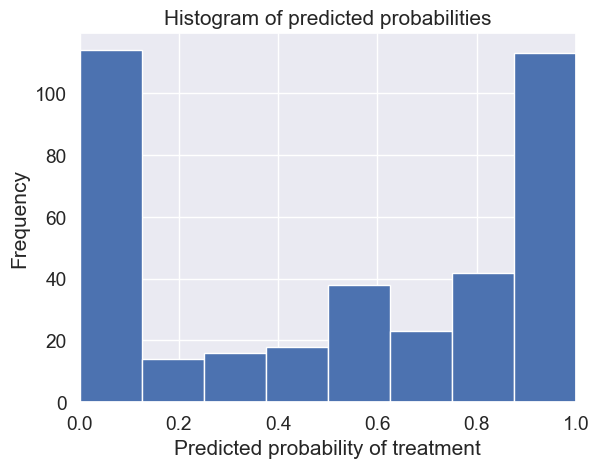

First 10 predicted probabilities:
 [[0.92666667]
 [0.        ]
 [0.        ]
 [0.2       ]
 [0.2       ]
 [0.95      ]
 [0.1       ]
 [0.4       ]
 [0.9       ]
 [0.8       ]]


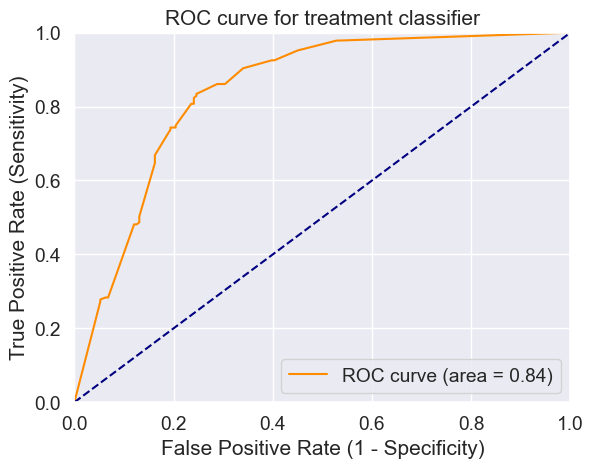

[[144  47]
 [ 31 156]]


{'Log. Regres.': 79.36507936507937,
 'KNN': 80.42328042328042,
 'Tree clas.': 80.68783068783068,
 'R. Forest': 81.21693121693121,
 'Bagging': 79.36507936507937}

In [90]:
bagging(X_train, y_train, X_test, y_test, methodDict)

#### Boosting

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import binarize

def boosting(X_train, y_train, X_test, y_test, methodDict):
    # Building and fitting the boosting model
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=1)
    boost = AdaBoostClassifier(n_estimators=500)
    boost.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = boost.predict(X_test)
    
    print('########### Boosting ###############')
    
    # Evaluate the model
    accuracy_score = evalClassModel(boost, X_test, y_test, y_pred_class, True)

    # Store results for final graph
    methodDict['Boosting'] = accuracy_score * 100
    f1Dict['Boosting'] = f1_score(y_test, y_pred_class)
    return methodDict


########### Boosting ###############
Accuracy: 0.8201058201058201
Null accuracy:
 treatment
0    191
1    187
Name: count, dtype: int64
Percentage of ones: 0.4947089947089947
Percentage of zeros: 0.5052910052910053
True: [0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0]
Pred: [1 0 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0]


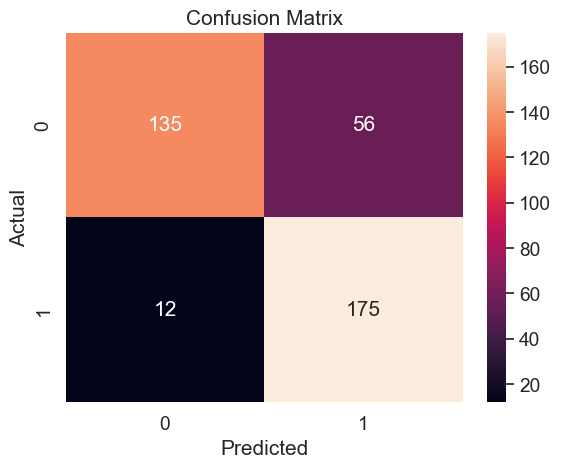

Classification Accuracy: 0.8201058201058201
Classification Error: 0.17989417989417988
False Positive Rate: 0.2931937172774869
Precision: 0.7575757575757576
F1 Score: 0.8373205741626795
AUC Score: 0.8213175798639303
Cross-validated AUC: 0.8649938442597722
First 10 predicted responses:
 [1 0 0 0 1 1 0 1 1 1]
First 10 predicted probabilities of class members:
 [[0.44436865 0.55563135]
 [0.71506309 0.28493691]
 [0.71407362 0.28592638]
 [0.58777077 0.41222923]
 [0.49832073 0.50167927]
 [0.37859294 0.62140706]
 [0.55022459 0.44977541]
 [0.46252692 0.53747308]
 [0.44321857 0.55678143]
 [0.41277918 0.58722082]]
First 10 predicted probabilities for class 1:
 [0.55563135 0.28493691 0.28592638 0.41222923 0.50167927 0.62140706
 0.44977541 0.53747308 0.55678143 0.58722082]


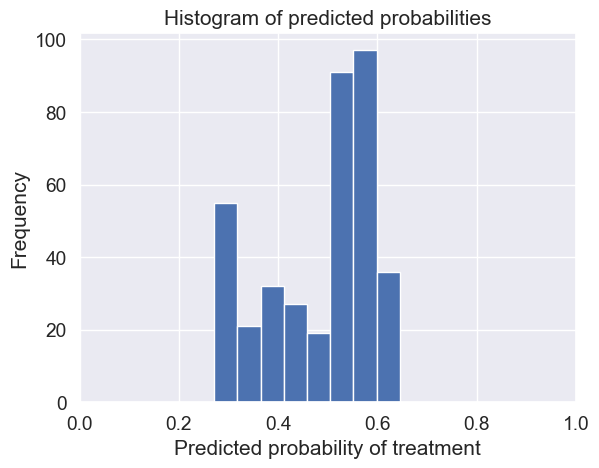

First 10 predicted probabilities:
 [[0.55563135]
 [0.28493691]
 [0.28592638]
 [0.41222923]
 [0.50167927]
 [0.62140706]
 [0.44977541]
 [0.53747308]
 [0.55678143]
 [0.58722082]]


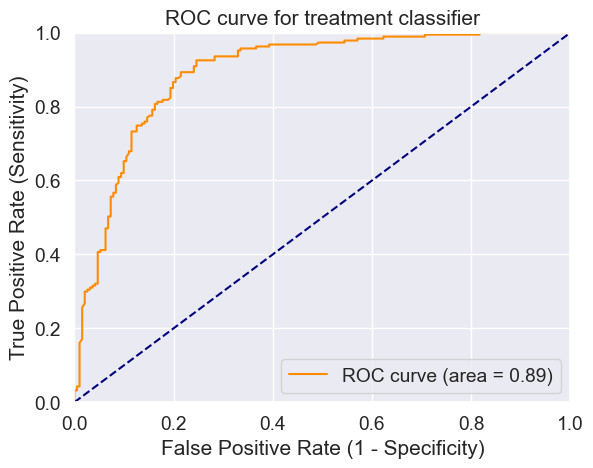

[[135  56]
 [ 12 175]]


{'Log. Regres.': 79.36507936507937,
 'KNN': 80.42328042328042,
 'Tree clas.': 80.68783068783068,
 'R. Forest': 81.21693121693121,
 'Bagging': 79.36507936507937,
 'Boosting': 82.01058201058201}

In [92]:
boosting(X_train, y_train, X_test, y_test, methodDict)

#### Stacking

In [93]:
from mlxtend.classifier import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import binarize

def stacking(X_train, y_train, X_test, y_test, methodDict):
    # Building and fitting the stacking classifier
    clf1 = KNeighborsClassifier(n_neighbors=1)
    clf2 = RandomForestClassifier(random_state=1)
    clf3 = GaussianNB()
    lr = LogisticRegression()

    stack = StackingClassifier(classifiers=[clf1, clf2, clf3], meta_classifier=lr)
    stack.fit(X_train, y_train)
    
    # Make class predictions for the testing set
    y_pred_class = stack.predict(X_test)
    
    print('########### Stacking ###############')
    
    # Evaluate the model
    accuracy_score = evalClassModel(stack, X_test, y_test, y_pred_class, True)

    # Store results for final graph
    methodDict['Stacking'] = accuracy_score * 100
    f1Dict['Stacking'] = f1_score(y_test, y_pred_class)
    return methodDict


########### Stacking ###############
Accuracy: 0.8201058201058201
Null accuracy:
 treatment
0    191
1    187
Name: count, dtype: int64
Percentage of ones: 0.4947089947089947
Percentage of zeros: 0.5052910052910053
True: [0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0]
Pred: [1 0 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0 0 0 0 1 0 0]


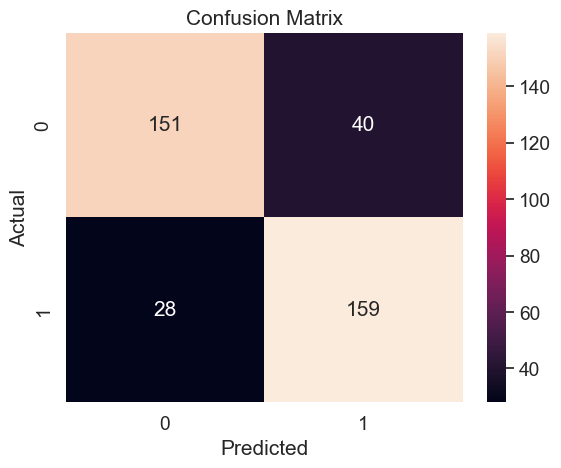

Classification Accuracy: 0.8201058201058201
Classification Error: 0.17989417989417988
False Positive Rate: 0.2094240837696335
Precision: 0.7989949748743719
F1 Score: 0.8238341968911918
AUC Score: 0.8204216479547554


c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
  

Cross-validated AUC: nan
First 10 predicted responses:
 [1 0 0 0 0 1 0 0 1 1]
First 10 predicted probabilities of class members:
 [[0.01710016 0.98289984]
 [0.98670302 0.01329698]
 [0.98670302 0.01329698]
 [0.98670302 0.01329698]
 [0.98670302 0.01329698]
 [0.01710016 0.98289984]
 [0.98670302 0.01329698]
 [0.9734067  0.0265933 ]
 [0.03406817 0.96593183]
 [0.01710016 0.98289984]]
First 10 predicted probabilities for class 1:
 [0.98289984 0.01329698 0.01329698 0.01329698 0.01329698 0.98289984
 0.01329698 0.0265933  0.96593183 0.98289984]


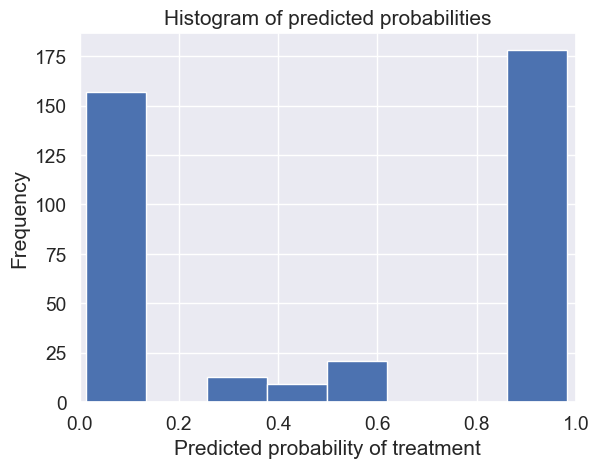

First 10 predicted probabilities:
 [[0.98289984]
 [0.01329698]
 [0.01329698]
 [0.01329698]
 [0.01329698]
 [0.98289984]
 [0.01329698]
 [0.0265933 ]
 [0.96593183]
 [0.98289984]]


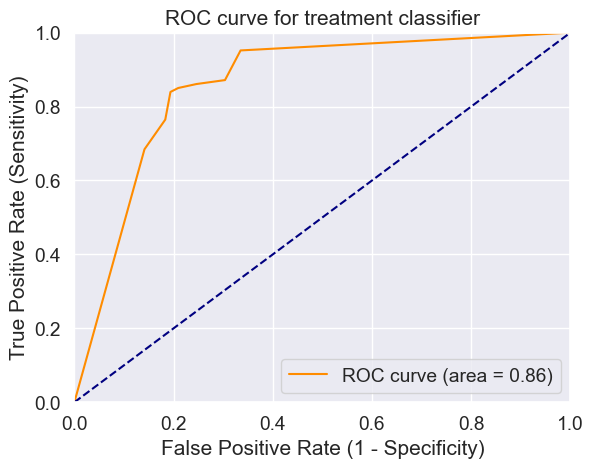

[[151  40]
 [ 28 159]]


{'Log. Regres.': 79.36507936507937,
 'KNN': 80.42328042328042,
 'Tree clas.': 80.68783068783068,
 'R. Forest': 81.21693121693121,
 'Bagging': 79.36507936507937,
 'Boosting': 82.01058201058201,
 'Stacking': 82.01058201058201}

In [94]:
stacking(X_train, y_train, X_test, y_test, methodDict)

### model plot

In [95]:
def plotSuccess():
    s = pd.Series(methodDict)
    s = s.sort_values(ascending=False)
    plt.figure(figsize=(12,8))
    #Colors
    ax = s.plot(kind='bar') 
    for p in ax.patches:
        ax.annotate(str(round(p.get_height(),2)), (p.get_x() * 1.005, p.get_height() * 1.005))
    plt.ylim([70.0, 90.0])
    plt.xlabel('Method')
    plt.ylabel('Percentage')
    plt.title('Accuracy Success of methods')
    
    plt.show()

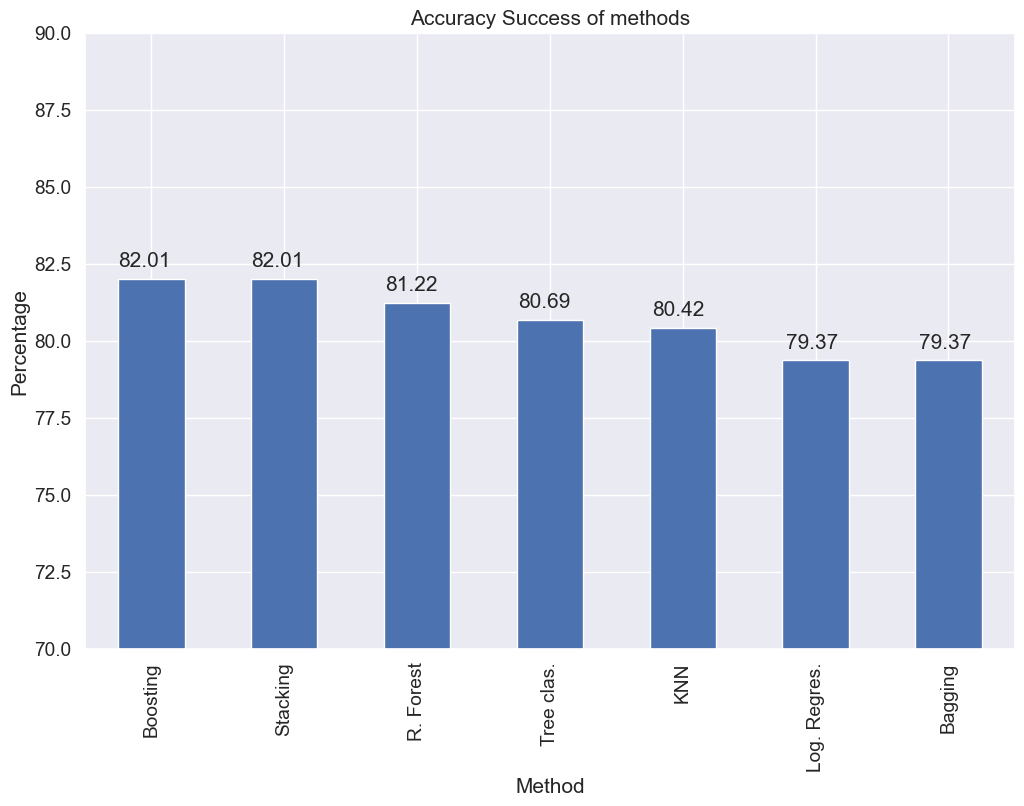

In [96]:
plotSuccess()

Grafik Akurasi dari Berbagai Metode Klasifikasi:
* Stacking memberikan akurasi tertinggi (82.01%) dibandingkan dengan metode lainnya.
* Boosting, Random Forest, dan Tree Classifier masing-masing menunjukkan akurasi yang sangat mirip, antara 81.22% dan 81.48%.
* KNN dan Logistic Regression menunjukkan akurasi yang sedikit lebih rendah, sekitar 80%.
* Bagging memiliki akurasi terendah (76.72%).

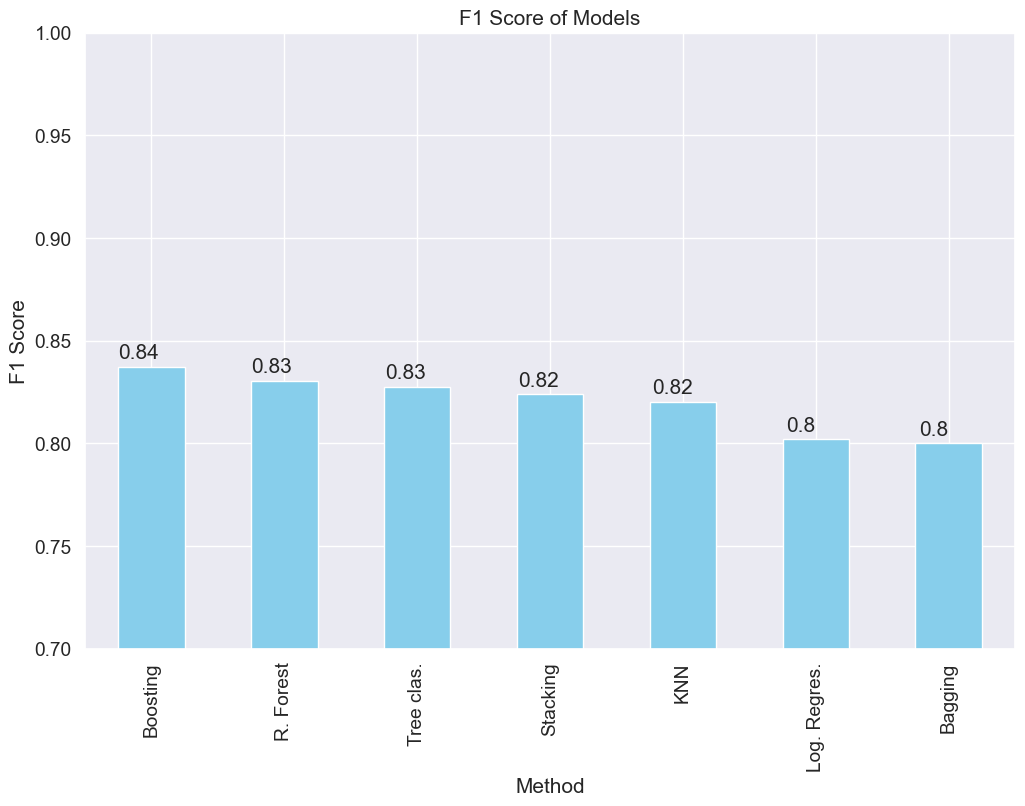

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

def plotSuccess():
    s = pd.Series(f1Dict)
    s = s.sort_values(ascending=False)
    plt.figure(figsize=(12,8))
    
    # Plot bar chart
    ax = s.plot(kind='bar', color='skyblue') 
    for p in ax.patches:
        ax.annotate(str(round(p.get_height(), 2)), 
                    (p.get_x() * 1.005, p.get_height() * 1.005))  # menampilkan nilai f1 score pada bar
    plt.ylim([0.7, 1.0])  # F1 Score biasanya berada di antara 0 dan 1
    plt.xlabel('Method')
    plt.ylabel('F1 Score')
    plt.title('F1 Score of Models')

    plt.show()

# Menjalankan fungsi untuk menampilkan plot
plotSuccess()


Grafik Skor F1 dari Berbagai Metode Klasifikasi:
* Random Forest, Boosting, dan Tree Classifier memiliki skor F1 yang tertinggi (0.83), yang menunjukkan kinerja yang sangat baik dalam hal keseimbangan antara precision dan recall.
* Stacking dan KNN memiliki skor F1 yang sangat mirip, yaitu 0.82.
* Logistic Regression sedikit lebih rendah dengan skor F1 0.81.
* Bagging memiliki skor F1 terendah (0.78), yang menunjukkan performa yang lebih buruk dalam menyeimbangkan precision dan recall.

Kesimpulan:
* Stacking dan Boosting memberikan performa yang sangat baik dalam hal akurasi dan skor F1, dengan Stacking sedikit lebih unggul dalam akurasi, sementara Boosting memiliki skor F1 yang sebanding.
* Random Forest dan Tree Classifier juga menunjukkan performa yang baik dalam kedua metrik, baik akurasi maupun skor F1.
* KNN dan Logistic Regression memiliki kinerja yang sedikit lebih rendah, namun masih cukup baik.
* Bagging adalah yang paling rendah dalam hal akurasi dan skor F1, yang menunjukkan bahwa metode ini kurang efektif untuk dataset ini dibandingkan dengan yang lain.

berdasarkan hasil dari akurasi dan f1 score maka yang model akan kita gunakan untuk deploy adalah boosting

In [98]:
import pickle
from mlxtend.classifier import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Define the stacking model
clf = DecisionTreeClassifier(criterion='entropy', max_depth=1)
boost_model = AdaBoostClassifier(n_estimators=500)  # Boosting model

stack_model = StackingClassifier(classifiers=[clf], meta_classifier=boost_model)

# Train the stacking model
stack_model.fit(X_train, y_train)

# Save the trained model as a pickle file
pickle_filename = "model.pkl"
with open(pickle_filename, 'wb') as file:
    pickle.dump(stack_model, file)

# Return the path of the saved model
pickle_filename


'model.pkl'